In [1]:
import pandas as pd
import os

In [2]:
colunas = [
    'NU_ANO_CENSO',
    'CO_ENTIDADE',
    'QT_MAT_BAS', 'QT_MAT_INF', 'QT_MAT_INF_CRE', 'QT_MAT_INF_PRE',
    'QT_MAT_FUND', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF',
    'QT_MAT_MED', 'QT_MAT_PROF', 'QT_MAT_PROF_TEC',
    'QT_MAT_EJA',
    'QT_DOC_INF', 'QT_DOC_INF_CRE', 'QT_DOC_INF_PRE',
    'QT_DOC_FUND', 'QT_DOC_FUND_AI', 'QT_DOC_FUND_AF',
    'QT_DOC_MED', 'QT_DOC_PROF', 'QT_DOC_PROF_TEC',
    'QT_DOC_EJA',
    'IN_EJA'
]

In [3]:
caminhos = {
    2022: '../data/microdados_censo_escolar_2022/microdados/dados/microdados_ed_basica_2022.csv',
    2023: '../data/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv',
    2024: '../data/microdados_censo_escolar_2024/dados/microdados_ed_basica_2024.csv'
}

In [4]:
dfs = []
for ano, caminho in caminhos.items():
    print(f'Lendo dados de {ano}...')
    df_ano = pd.read_csv(caminho, encoding='latin-1', sep=';', low_memory=False, usecols=colunas)
    dfs.append(df_ano)
    print(f'{ano}: {df_ano.shape[0]} escolas carregadas')

Lendo dados de 2022...
2022: 224649 escolas carregadas
Lendo dados de 2023...
2023: 217625 escolas carregadas
Lendo dados de 2024...
2024: 215545 escolas carregadas


In [5]:
df = pd.concat(dfs, ignore_index=True)
print(f'DataFrame consolidado: {df.shape[0]} registros x {df.shape[1]} colunas')
df.head()

DataFrame consolidado: 657819 registros x 24 colunas


,NU_ANO_CENSO,CO_ENTIDADE,IN_EJA,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AF,...,QT_DOC_INF,QT_DOC_INF_CRE,QT_DOC_INF_PRE,QT_DOC_FUND,QT_DOC_FUND_AI,QT_DOC_FUND_AF,QT_DOC_MED,QT_DOC_PROF,QT_DOC_PROF_TEC,QT_DOC_EJA
0,2022,11022558,0.0,6.0,0.0,0.0,0.0,6.0,6.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2022,11024275,1.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
2,2022,11024291,0.0,9.0,0.0,0.0,0.0,9.0,9.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2022,11024372,0.0,118.0,17.0,0.0,17.0,101.0,43.0,58.0,...,1.0,0.0,1.0,7.0,1.0,6.0,0.0,0.0,0.0,0.0
4,2022,11024666,0.0,161.0,18.0,0.0,18.0,143.0,66.0,77.0,...,1.0,0.0,1.0,19.0,3.0,16.0,0.0,0.0,0.0,0.0


In [6]:
# Filtrar escolas com EJA
df_eja = df[df['IN_EJA'] == 1].copy()
print(f'Total de escolas com EJA: {len(df_eja)}')
df_eja.head()

Total de escolas com EJA: 89405


,NU_ANO_CENSO,CO_ENTIDADE,IN_EJA,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AF,...,QT_DOC_INF,QT_DOC_INF_CRE,QT_DOC_INF_PRE,QT_DOC_FUND,QT_DOC_FUND_AI,QT_DOC_FUND_AF,QT_DOC_MED,QT_DOC_PROF,QT_DOC_PROF_TEC,QT_DOC_EJA
1,2022,11024275,1.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
37,2022,11006757,1.0,666.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0
39,2022,11006773,1.0,1434.0,0.0,0.0,0.0,1193.0,0.0,1193.0,...,0.0,0.0,0.0,41.0,0.0,41.0,0.0,0.0,0.0,13.0
50,2022,11007281,1.0,620.0,0.0,0.0,0.0,466.0,0.0,466.0,...,0.0,0.0,0.0,21.0,0.0,21.0,0.0,0.0,0.0,15.0
53,2022,11007451,1.0,950.0,0.0,0.0,0.0,818.0,678.0,140.0,...,0.0,0.0,0.0,28.0,27.0,9.0,0.0,0.0,0.0,12.0


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

plt.style.use('seaborn-v0_8')

In [8]:
# Remover outliers baseados em QT_MAT_BAS usando desvio-padrão
mean_mat_bas = df_eja['QT_MAT_BAS'].mean()
std_mat_bas = df_eja['QT_MAT_BAS'].std()

# Definir limite: 3 desvios-padrão da média
limite_superior = mean_mat_bas + 3 * std_mat_bas
limite_inferior = mean_mat_bas - 3 * std_mat_bas

print(f'Média QT_MAT_BAS: {mean_mat_bas:.2f}')
print(f'Desvio-padrão QT_MAT_BAS: {std_mat_bas:.2f}')
print(f'Limite inferior: {limite_inferior:.2f}')
print(f'Limite superior: {limite_superior:.2f}')

# Filtrar outliers
df_eja_sem_outliers = df_eja[(df_eja['QT_MAT_BAS'] >= limite_inferior) & (df_eja['QT_MAT_BAS'] <= limite_superior)].copy()

print(f'\nTotal antes da remoção: {len(df_eja)}')
print(f'Total após remoção: {len(df_eja_sem_outliers)}')
print(f'Outliers removidos: {len(df_eja) - len(df_eja_sem_outliers)}')

# Atualizar df_eja
df_eja = df_eja_sem_outliers

Média QT_MAT_BAS: 407.16
Desvio-padrão QT_MAT_BAS: 474.50
Limite inferior: -1016.33
Limite superior: 1830.64

Total antes da remoção: 89405
Total após remoção: 88685
Outliers removidos: 720


In [9]:
# Preparar dados para clusterização
colunas_cluster = [col for col in df_eja.columns if col not in ['NU_ANO_CENSO', 'CO_ENTIDADE', 'IN_EJA']]
df_cluster = df_eja[colunas_cluster].copy()

# Tratar valores nulos - preencher com 0
df_cluster = df_cluster.fillna(0)

print(f'Dados para clusterização: {df_cluster.shape[0]} registros x {df_cluster.shape[1]} colunas')
print(f'Colunas usadas: {colunas_cluster}')

Dados para clusterização: 88685 registros x 21 colunas
Colunas usadas: ['QT_MAT_BAS', 'QT_MAT_INF', 'QT_MAT_INF_CRE', 'QT_MAT_INF_PRE', 'QT_MAT_FUND', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF', 'QT_MAT_MED', 'QT_MAT_PROF', 'QT_MAT_PROF_TEC', 'QT_MAT_EJA', 'QT_DOC_INF', 'QT_DOC_INF_CRE', 'QT_DOC_INF_PRE', 'QT_DOC_FUND', 'QT_DOC_FUND_AI', 'QT_DOC_FUND_AF', 'QT_DOC_MED', 'QT_DOC_PROF', 'QT_DOC_PROF_TEC', 'QT_DOC_EJA']


In [10]:
# Escalar os dados
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

print(f'Dados escalados: {df_scaled.shape}')
print(f'Média por feature (após escala): {df_scaled.mean(axis=0)[:5]}')
print(f'Desvio padrão por feature (após escala): {df_scaled.std(axis=0)[:5]}')

Dados escalados: (88685, 21)
Média por feature (após escala): [-7.69150393e-18 -3.65346437e-17 -2.05106772e-17 -3.52527264e-17
 -4.48671063e-17]
Desvio padrão por feature (após escala): [1. 1. 1. 1. 1.]


In [11]:
# # Método do cotovelo para encontrar número ideal de clusters
# inertias = []
# silhouette_scores = []
# k_range = range(2, 11)

# for k in k_range:
#     print(k)
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans.fit(df_scaled)
#     inertias.append(kmeans.inertia_)
#     silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# # Plotar método do cotovelo
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ax1.plot(k_range, inertias, 'bo-', markersize=8)
# ax1.set_xlabel('Número de Clusters (k)')
# ax1.set_ylabel('Inércia')
# ax1.set_title('Método do Cotovelo')
# ax1.grid(True, alpha=0.3)

# ax2.plot(k_range, silhouette_scores, 'ro-', markersize=8)
# ax2.set_xlabel('Número de Clusters (k)')
# ax2.set_ylabel('Silhouette Score')
# ax2.set_title('Silhouette Score por k')
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Exibir valores
# print('Valores de Inércia:', dict(zip(k_range, inertias)))
# print('Valores de Silhouette:', dict(zip(k_range, silhouette_scores)))

In [12]:
# Treinar KMeans com k ótimo (baseado no método do cotovelo e silhouette)
k_optimo = 4  # Ajuste este valor após analisar os gráficos anteriores
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans.fit(df_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print(f'KMeans treinado com k={k_optimo}')
print(f'Inércia: {kmeans.inertia_:.2f}')
print(f'Distribuição dos clusters: {np.bincount(labels)}')

KMeans treinado com k=4
Inércia: 1081924.81
Distribuição dos clusters: [ 6405 59296 21681  1303]


In [13]:
# Calcular métricas de avaliação do cluster
silhouette_avg = silhouette_score(df_scaled, labels)
# calinski_harabasz = calinski_harabasz_score(df_scaled, labels)
# davies_bouldin = davies_bouldin_score(df_scaled, labels)

print('Métricas de Avaliação do Cluster:')
print(f'  Silhouette Score: {silhouette_avg:.4f} (varia de -1 a 1, quanto maior melhor)')
# print(f'  Calinski-Harabasz Index: {calinski_harabasz:.2f} (quanto maior melhor)')
# print(f'  Davies-Bouldin Index: {davies_bouldin:.4f} (quanto menor melhor)')
print(f'  Inércia: {kmeans.inertia_:.2f}')

Métricas de Avaliação do Cluster:
  Silhouette Score: 0.3605 (varia de -1 a 1, quanto maior melhor)
  Inércia: 1081924.81


In [14]:
# Adicionar coluna de cluster ao df_eja
df_eja['cluster'] = labels

print(f'Coluna cluster adicionada ao df_eja')
print(f'Distribuição de escolas por cluster:')
print(df_eja['cluster'].value_counts().sort_index())

Coluna cluster adicionada ao df_eja
Distribuição de escolas por cluster:
cluster
0     6405
1    59296
2    21681
3     1303
Name: count, dtype: int64


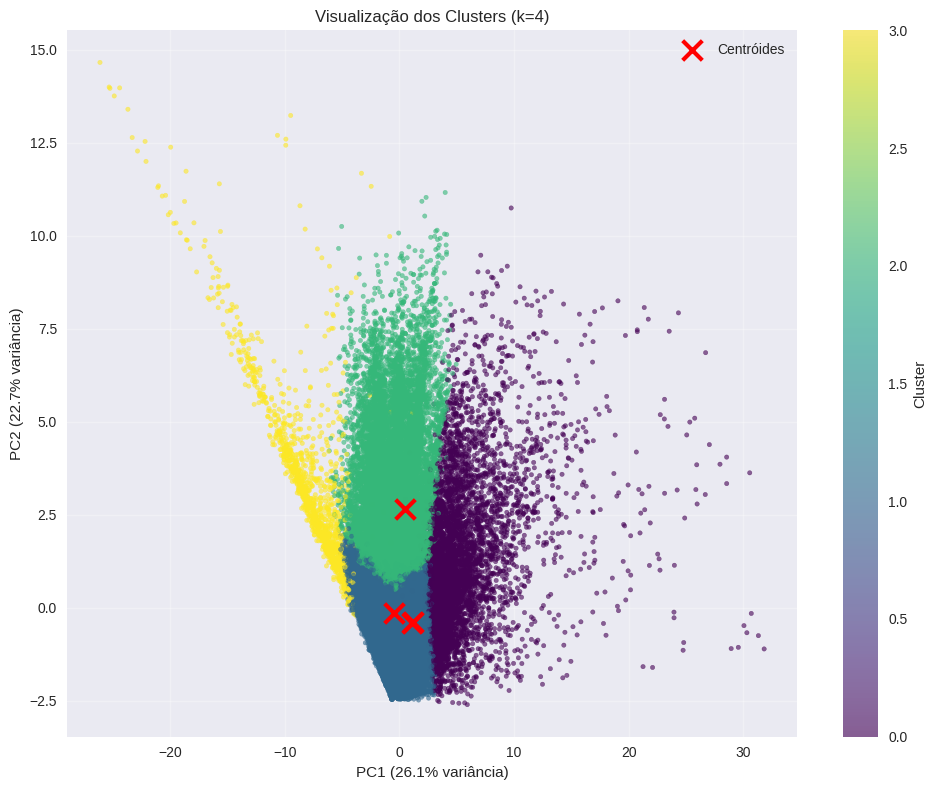

Variância explicada pelos 2 primeiros componentes: 48.84%


In [15]:
# Visualizar clusters usando PCA para redução de dimensionalidade
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Plotar clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidths=3, label='Centróides')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.title(f'Visualização dos Clusters (k={k_optimo})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Variância explicada pelos 2 primeiros componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%')

In [16]:
# Exibir centróides na escala original (antes do Scaler)
centroids_original = scaler.inverse_transform(centroids)
df_centroids = pd.DataFrame(centroids_original, columns=colunas_cluster)

print(f'Centróides dos {k_optimo} clusters (valores originais):')
print(df_centroids.T)

Centróides dos 4 clusters (valores originais):
                          0           1           2           3
QT_MAT_BAS       564.997658  210.872390  801.621571  794.912510
QT_MAT_INF       116.891179   10.776741    1.910084    0.741366
QT_MAT_INF_CRE    24.964715    3.508011    0.083460    0.300077
QT_MAT_INF_PRE    91.926464    7.268730    1.826624    0.441289
QT_MAT_FUND      370.797190   75.757025  499.648914   27.475825
QT_MAT_FUND_AI   272.272756   45.375898  145.679163    3.412126
QT_MAT_FUND_AF    98.524434   30.381127  353.969751   24.063699
QT_MAT_MED         2.545199   60.521370  166.804261  481.494244
QT_MAT_PROF        2.107260    7.109664   11.094527  586.428243
QT_MAT_PROF_TEC    0.414676    4.621353    6.779776  576.055257
QT_MAT_EJA        74.196877   61.875156  129.882095  121.554106
QT_DOC_INF         8.384387    0.852218    0.121778    0.056792
QT_DOC_INF_CRE     2.285090    0.249368    0.006363    0.022256
QT_DOC_INF_PRE     6.501171    0.650531    0.116568    0.

In [17]:
# Listar escolas do cluster 3
escolas_cluster_3 = df_eja[df_eja['cluster'] == 3]
print(f'Total de escolas no cluster 3: {len(escolas_cluster_3)}')
escolas_cluster_3

Total de escolas no cluster 3: 1303


,NU_ANO_CENSO,CO_ENTIDADE,IN_EJA,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AF,...,QT_DOC_INF_CRE,QT_DOC_INF_PRE,QT_DOC_FUND,QT_DOC_FUND_AI,QT_DOC_FUND_AF,QT_DOC_MED,QT_DOC_PROF,QT_DOC_PROF_TEC,QT_DOC_EJA,cluster
2446,2022,12028843,1.0,871.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,33.0,33.0,1.0,3
4515,2022,13116401,1.0,531.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,32.0,32.0,32.0,14.0,3
4641,2022,13101153,1.0,434.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,12.0,3
4953,2022,13101137,1.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,28.0,30.0,30.0,6.0,3
6120,2022,13026844,1.0,971.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,65.0,85.0,85.0,28.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657363,2024,53015231,1.0,605.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,32.0,58.0,58.0,33.0,3
657364,2024,53015240,1.0,354.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,34.0,56.0,56.0,23.0,3
657372,2024,53015380,1.0,404.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,33.0,40.0,40.0,8.0,3
657373,2024,53015401,1.0,463.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,40.0,44.0,44.0,27.0,3


In [18]:
# Definir labels para cada cluster
label_mapping = {
    0: 'ESCOLA_TAMANHO_MEDIO',
    1: 'ESCOLA_PEQUENA',
    2: 'ESCOLA_FUND',
    3: 'ESCOLA_MED'
}

# Criar coluna com labels
df_eja['label_cluster'] = df_eja['cluster'].map(label_mapping)

print('Labels dos clusters:')
print(df_eja['label_cluster'].value_counts().sort_index())
print(f'\nDistribuição por label:')
print(df_eja[['cluster', 'label_cluster']].value_counts().sort_index())

Labels dos clusters:
label_cluster
ESCOLA_FUND             21681
ESCOLA_MED               1303
ESCOLA_PEQUENA          59296
ESCOLA_TAMANHO_MEDIO     6405
Name: count, dtype: int64

Distribuição por label:
cluster  label_cluster       
0        ESCOLA_TAMANHO_MEDIO     6405
1        ESCOLA_PEQUENA          59296
2        ESCOLA_FUND             21681
3        ESCOLA_MED               1303
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Preparar dados para classificação
# Remover colunas não utilizadas: NU_ANO_CENSO, CO_ENTIDADE, IN_EJA, cluster
colunas_features = [col for col in df_eja.columns if col not in ['NU_ANO_CENSO', 'CO_ENTIDADE', 'IN_EJA', 'cluster', 'label_cluster']]

X = df_eja[colunas_features].fillna(0)
y = df_eja['label_cluster']

# Dividir dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Treinar classificador Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Fazer previsões
y_pred = dt_classifier.predict(X_test)

# Avaliar modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy:.4f}')
print(f'\nRelatório de Classificação:')
print(classification_report(y_test, y_pred))

Acurácia: 0.9799

Relatório de Classificação:
                      precision    recall  f1-score   support

         ESCOLA_FUND       0.97      0.97      0.97      6504
          ESCOLA_MED       0.96      0.97      0.97       391
      ESCOLA_PEQUENA       0.99      0.99      0.99     17789
ESCOLA_TAMANHO_MEDIO       0.96      0.95      0.95      1922

            accuracy                           0.98     26606
           macro avg       0.97      0.97      0.97     26606
        weighted avg       0.98      0.98      0.98     26606



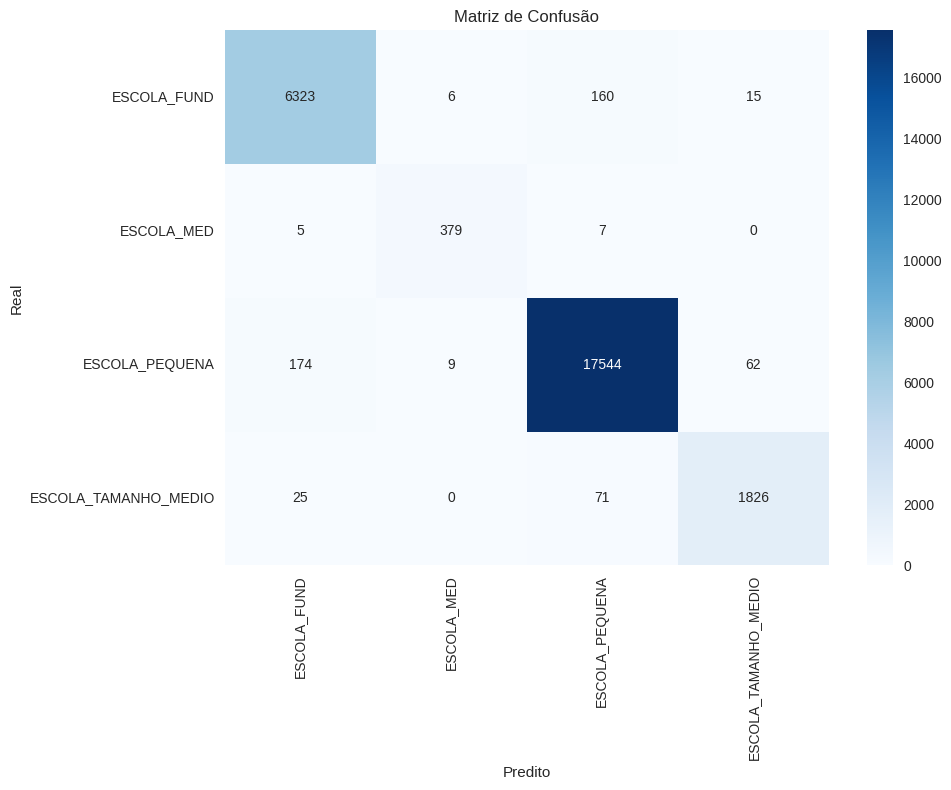

In [20]:
# Plotar matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=dt_classifier.classes_,
            yticklabels=dt_classifier.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.show()

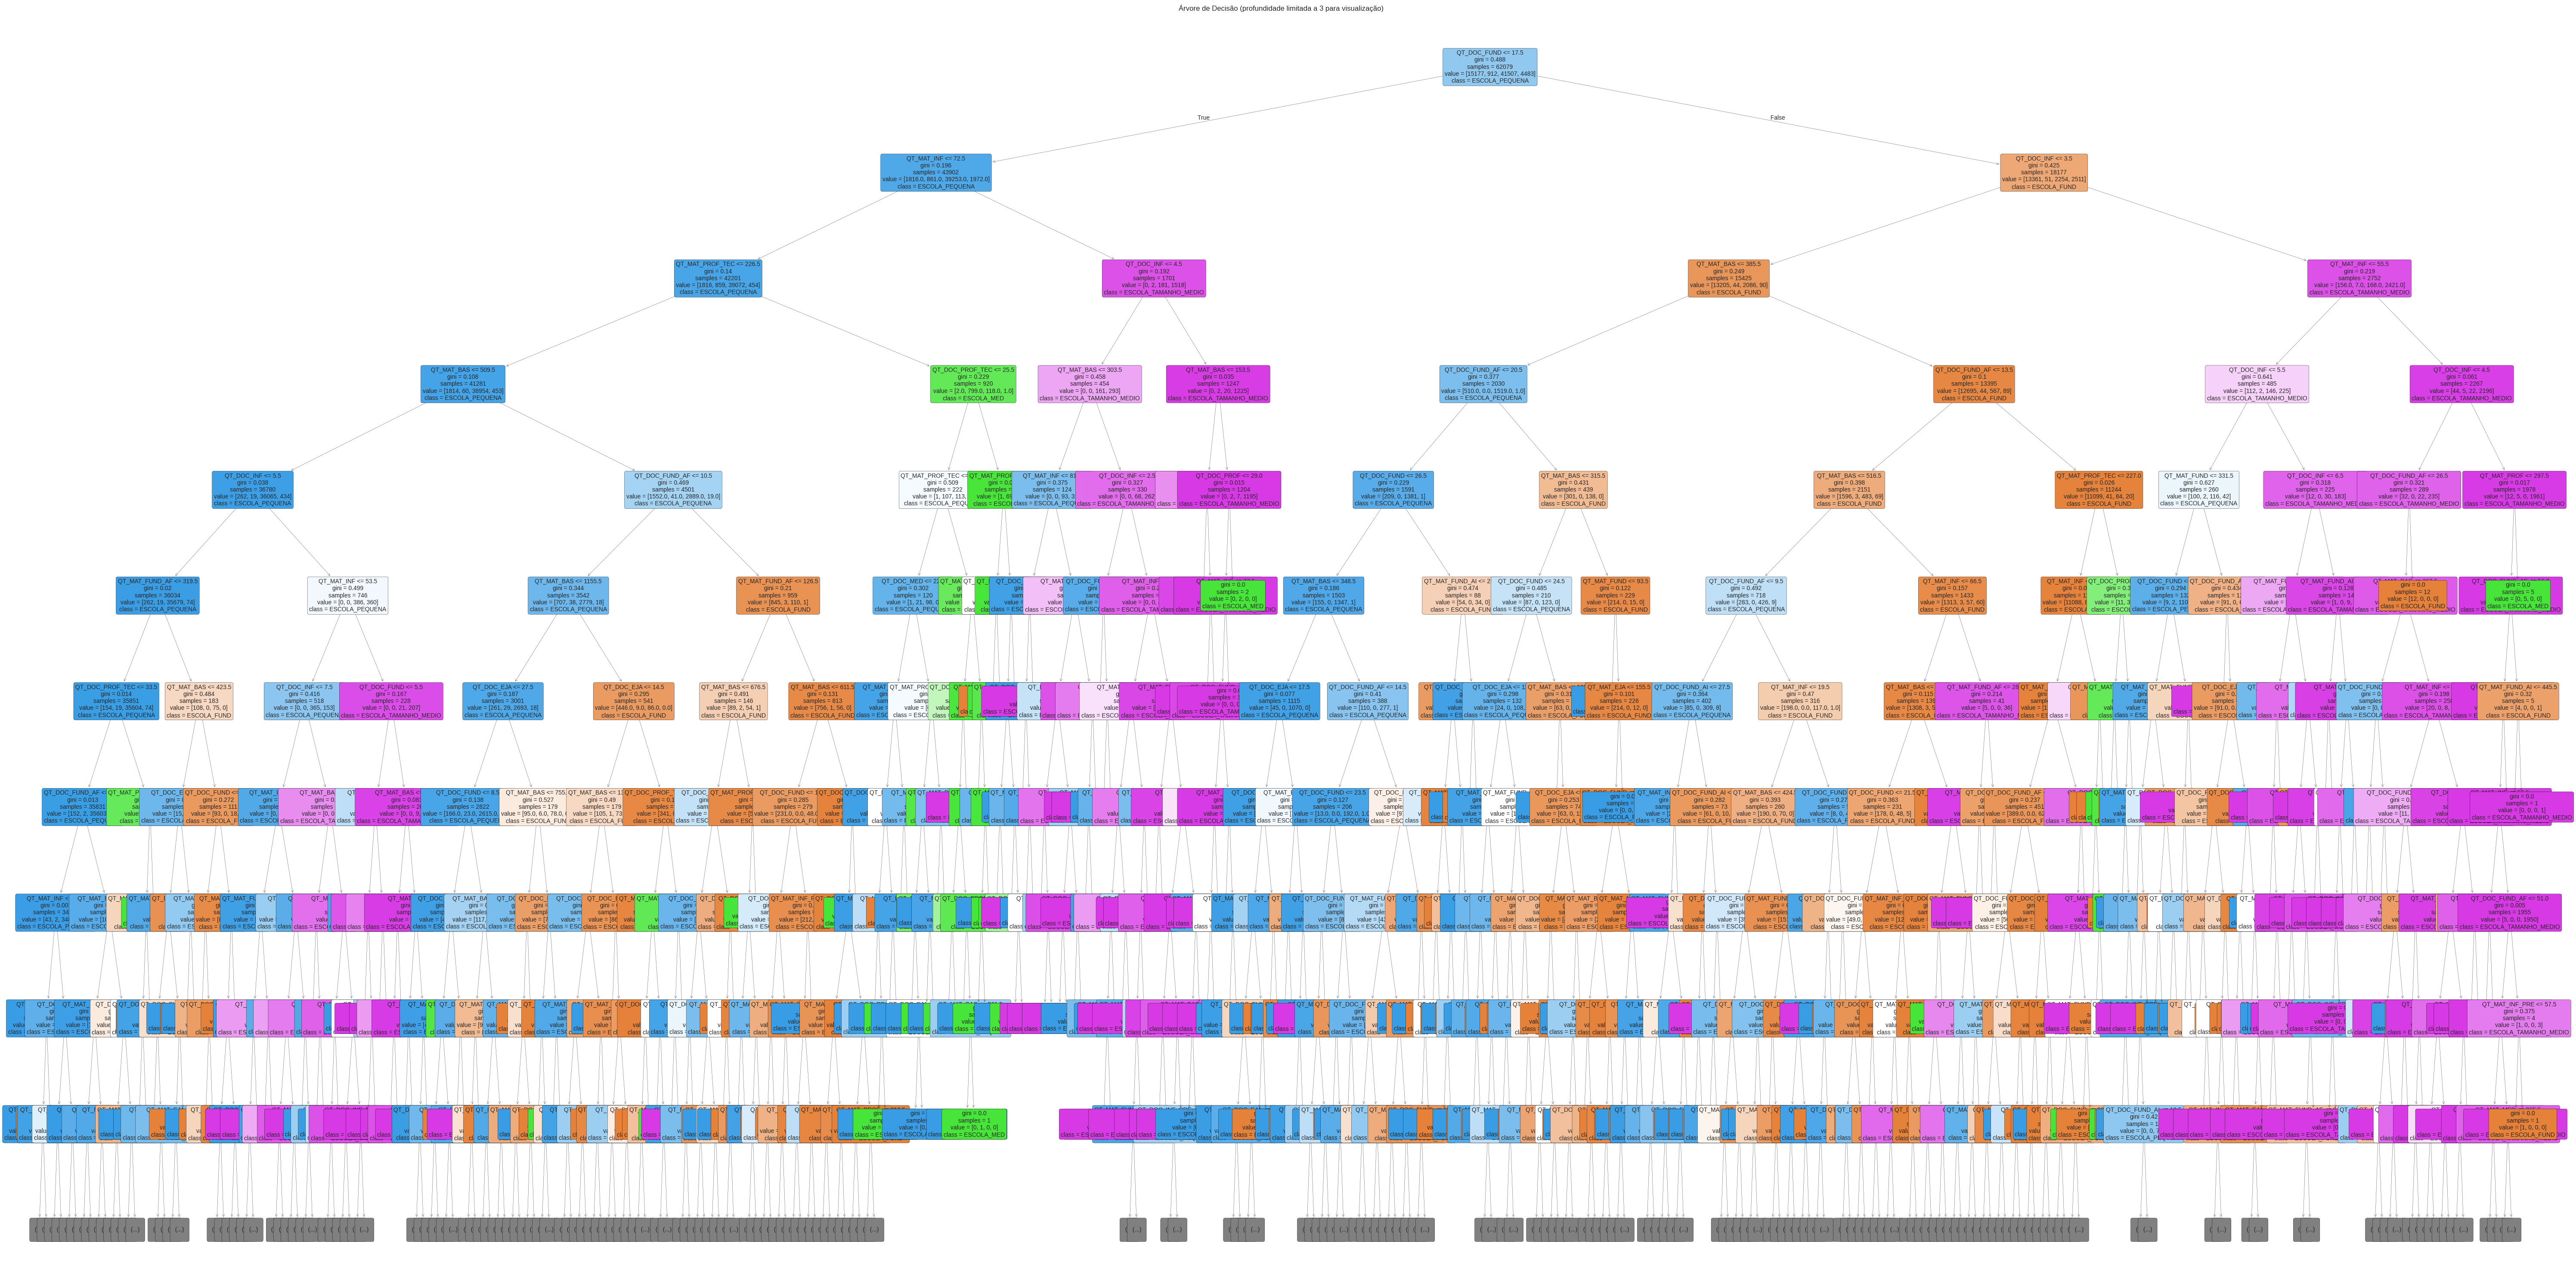

In [21]:
# Plotar árvore de decisão
from sklearn.tree import plot_tree

plt.figure(figsize=(60, 30))
plot_tree(dt_classifier, 
          feature_names=X.columns, 
          class_names=dt_classifier.classes_,
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=10)
plt.title('Árvore de Decisão (profundidade limitada a 3 para visualização)')
plt.tight_layout()
plt.show()

In [22]:
# Exibir regras da árvore de decisão como texto
from sklearn.tree import export_text

tree_rules = export_text(dt_classifier, feature_names=list(X.columns), max_depth=3)
print('Regras da Árvore de Decisão (profundidade limitada a 3):')
print(tree_rules)

Regras da Árvore de Decisão (profundidade limitada a 3):
|--- QT_DOC_FUND <= 17.50
|   |--- QT_MAT_INF <= 72.50
|   |   |--- QT_MAT_PROF_TEC <= 226.50
|   |   |   |--- QT_MAT_BAS <= 509.50
|   |   |   |   |--- truncated branch of depth 19
|   |   |   |--- QT_MAT_BAS >  509.50
|   |   |   |   |--- truncated branch of depth 15
|   |   |--- QT_MAT_PROF_TEC >  226.50
|   |   |   |--- QT_DOC_PROF_TEC <= 25.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- QT_DOC_PROF_TEC >  25.50
|   |   |   |   |--- truncated branch of depth 6
|   |--- QT_MAT_INF >  72.50
|   |   |--- QT_DOC_INF <= 4.50
|   |   |   |--- QT_MAT_BAS <= 303.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- QT_MAT_BAS >  303.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- QT_DOC_INF >  4.50
|   |   |   |--- QT_MAT_BAS <= 153.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- QT_MAT_BAS >  153.50
|   |   |   |   |--- truncated branch of depth 6
|--- QT_DOC

/tmp/ipykernel_459334/2130420497.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


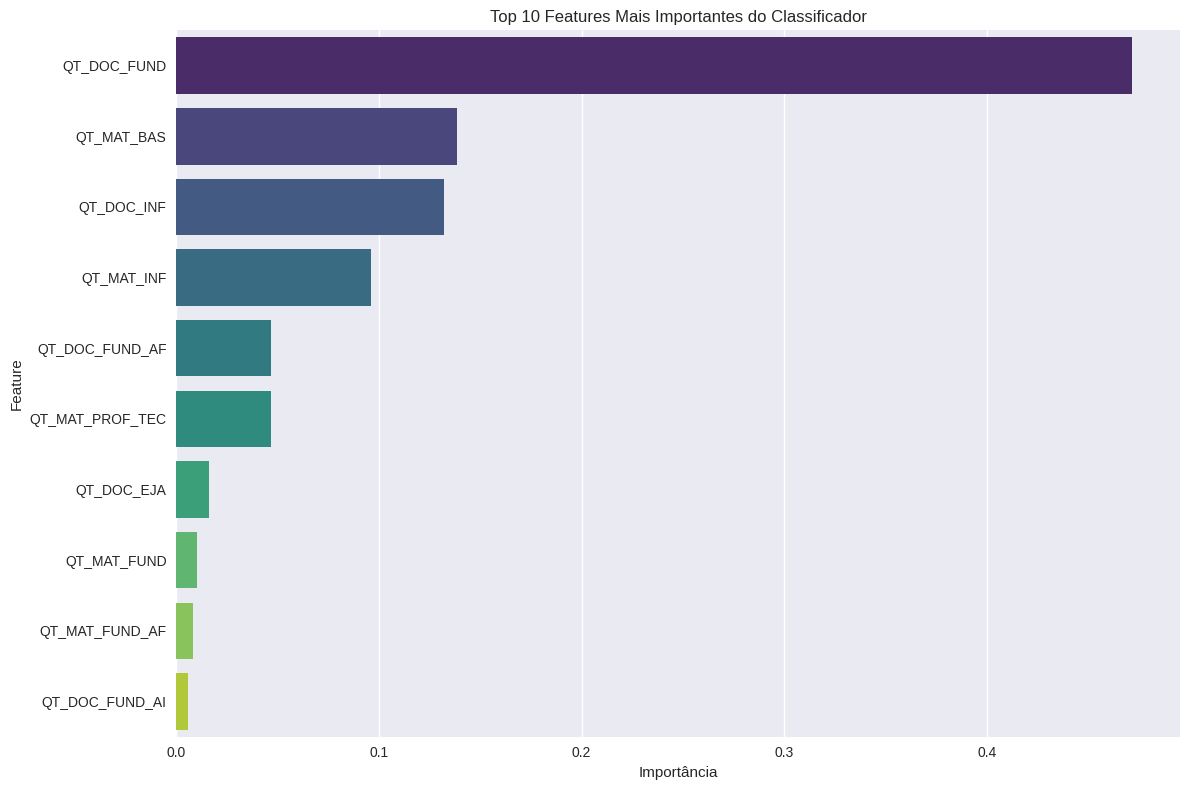

Top 10 Features Mais Importantes:
        feature  importance
    QT_DOC_FUND    0.471718
     QT_MAT_BAS    0.138476
     QT_DOC_INF    0.132036
     QT_MAT_INF    0.096035
 QT_DOC_FUND_AF    0.046615
QT_MAT_PROF_TEC    0.046528
     QT_DOC_EJA    0.016351
    QT_MAT_FUND    0.010461
 QT_MAT_FUND_AF    0.008149
 QT_DOC_FUND_AI    0.005949


In [23]:
# Plotar as 10 features mais importantes
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.title('Top 10 Features Mais Importantes do Classificador')
plt.tight_layout()
plt.show()

print('Top 10 Features Mais Importantes:')
print(feature_importance.to_string(index=False))

In [ ]:
import joblib
import os

# Criar diretório para salvar modelos se não existir
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Salvar o modelo dt_classifier
model_path = os.path.join(model_dir, 'dt_classifier.joblib')
joblib.dump(dt_classifier, model_path)
print(f'Modelo salvo em: {model_path}')
print(f'Tamanho do arquivo: {os.path.getsize(model_path) / 1024:.2f} KB')

Modelo salvo em: ../models/dt_classifier.joblib
Tamanho do arquivo: 171.62 KB
